# Comparing Model Performance after Fine-Tuning

In this notebook we evaluate the impact of fine-tuning on financial stock-forecasting quality. We run identical prompts from the **[FinGPT/fingpt-forecaster-dow30-202305-202405](https://huggingface.co/datasets/FinGPT/fingpt-forecaster-dow30-202305-202405)** dataset through both the base and fine-tuned endpoints and compare their outputs against the ground-truth `answer` column using **ROUGE scores** (ROUGE-1, ROUGE-2, ROUGE-L).

A higher ROUGE score on the fine-tuned model indicates that fine-tuning has improved the model's ability to produce structured financial analysis aligned with the expected analyst-style responses.

## Prerequisites

In [1]:
%pip install -r ./scripts/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 253.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 154.9 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.1
    Uninstalling tqdm-4.67.1:
      Successfully uninstalled tqdm-4.67.1
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 19.0.1
    Uninstalling pyarrow-19.0.1:
      Successfully uninstalled pyarrow-19.0.1━━━━━━━━━━━━━━━━━━━━━ 1/6 [pyarrow]
  Attempting uninstall: botocorem━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/6 [pyarrow]
    Found existing installation: botocore 1.43.23━━━━━━━━━━━━━ 1/6 [pyarrow]
    Uninstalling botocore-1.43.23:━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/6 [pyarrow]
      Successfully uninstalled botocore-1.43.23━━━━━━━━━━━━━━━ 1/6 [pyarrow]
  Attempting uninstall: s3transferm━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/6 [botocore]
    Found existing installation: s3transfer 0.18.0━━━━━━━━━━━━ 2/6 [botocore]
    Uninstalling s3transfe

## This cell will restart the kernel. Click "OK".

In [2]:
from IPython import get_ipython
get_ipython().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

In [1]:
# Import libraries
import os
import json
import time
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from datasets import load_dataset

# Import ROUGE scorer
from rouge_score import rouge_scorer
# Import v3 SDK
from sagemaker.core.resources import Endpoint

/opt/conda/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


#### Fetch the saved endpoint names from previous sections, or set them manually by uncommenting the code below. 

In [2]:
%store -r BASE_ENDPOINT_NAME
%store -r TUNED_ENDPOINT_NAME

#BASE_ENDPOINT_NAME = ""
#TUNED_ENDPOINT_NAME = ""

print(f"Base Endpoint: {BASE_ENDPOINT_NAME}")
print(f"Tuned Endpoint: {TUNED_ENDPOINT_NAME}")

Base Endpoint: Qwen3-4B-Instruct-2507-endpoint-2026-06-05-04-07-28-043
Tuned Endpoint: Qwen3-4B-Instruct-2507-sft-2026-06-05-05-11-34-504


In [3]:
# Define the model to evaluate
model_to_evaluate = {
    "name": "Fine-tuned Model", 
    "endpoint": TUNED_ENDPOINT_NAME
}

Load a random sample from the **FinGPT forecaster** test split. Each example contains a `prompt` (company news + financials) and an `answer` (structured analysis + prediction). The `answer` is used as the reference when computing ROUGE scores.

In [4]:
# Limit the number of samples to evaluate (for faster execution)
num_samples = 10

# Load the FinGPT forecaster dataset
dataset = load_dataset("FinGPT/fingpt-forecaster-dow30-202305-202405", split="test")

max_samples = len(dataset)

dataset = dataset.shuffle().select(range(min(num_samples, max_samples)))
print(f"Loaded fingpt-forecaster dataset with {len(dataset)} samples out of {max_samples}")

# Display a sample from the dataset
sample = dataset[0]

print("\nPrompt:\n", sample["prompt"][:500], "...\n\n====\n")
print("Answer:\n", sample["answer"][:500], "...\n\n====\n")
print("Symbol:", sample["symbol"], "| Period:", sample["period"], "| Label:", sample["label"])


Loaded fingpt-forecaster dataset with 10 samples out of 300

Prompt:
 [INST]<<SYS>>
You are a seasoned stock market analyst. Your task is to list the positive developments and potential concerns for companies based on relevant news and basic financials from the past weeks, then provide an analysis and prediction for the companies' stock price movement for the upcoming week. Your answer format should be as follows:

[Positive Developments]:
1. ...

[Potential Concerns]:
1. ...

[Prediction & Analysis]
Prediction: ...
Analysis: ...

<</SYS>>

[Company Introduction]: ...

====

Answer:
 [Positive Developments]:
1. Visa’s second-quarter results exceeded Wall Street estimates, demonstrating a reliable consumer spending habit and resilience against a potential slowing economy. This indicates a strengthened business performance and boosts investor confidence.
2. There is a growing recognition of Visa's significant potential as a future trillion-dollar company. This generates a positive image 

In [5]:
SYSTEM_PROMPT = """You are a seasoned stock market analyst. Your task is to list the positive developments and potential concerns for companies based on relevant news and basic financials from the past weeks, then provide an analysis and prediction for the companies' stock price movement for the upcoming week."""


def convert_to_messages(sample, system_prompt="", include_answer=True):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": sample["prompt"]},
    ]
    if include_answer:
        messages.append({"role": "assistant", "content": sample["answer"]})
    return messages


#### Next, we create helper functions for endpoint inference, ROUGE metric calculation, and full model evaluation on the FinGPT dataset.

In [6]:
# Initialize ROUGE scorer
rouge_metrics = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def calculate_metrics(predictions, references):
    metrics = {}
    rouge_scores = {'rouge1_f': [], 'rouge2_f': [], 'rougeL_f': []}
    
    for pred, ref in zip(predictions, references):
        rouge_result = rouge_metrics.score(ref, pred)
        rouge_scores['rouge1_f'].append(rouge_result['rouge1'].fmeasure)
        rouge_scores['rouge2_f'].append(rouge_result['rouge2'].fmeasure)
        rouge_scores['rougeL_f'].append(rouge_result['rougeL'].fmeasure)
    
    for key in rouge_scores:
        metrics[key] = sum(rouge_scores[key]) / len(rouge_scores[key])
    
    return metrics

[06/05/26 05:44:51] INFO     Using default tokenizer.                                            ]8;id=706102;file:///opt/conda/lib/python3.12/site-packages/rouge_score/rouge_scorer.py\rouge_scorer.py]8;;\:]8;id=623585;file:///opt/conda/lib/python3.12/site-packages/rouge_score/rouge_scorer.py#83\83]8;;\

In [7]:
def generate_summaries_with_model(endpoint_name, dataset):
    """
    Generate summaries using a model deployed on SageMaker.
    Uses v3 SDK Endpoint.invoke() instead of v2 Predictor.
    """
    predictions = []
    core_endpoint = Endpoint.get(endpoint_name=endpoint_name)

    for example in tqdm(dataset, desc="Generating Responses"):
        messages = convert_to_messages(example, system_prompt=SYSTEM_PROMPT, include_answer=False)
        
        payload = json.dumps({
            "messages": messages,
            "parameters": {
                "max_new_tokens": 512,
                "top_p": 0.9,
                "temperature": 0.6,
                "return_full_text": False
            }
        })
        
        try:
            response = core_endpoint.invoke(
                body=payload,
                content_type="application/json",
                accept="application/json",
            )
            result = json.loads(response.body.read().decode("utf-8"))
            prediction = result["choices"][0]["message"]["content"].strip()
        except Exception as e:
            print(f"Error invoking SageMaker endpoint {endpoint_name}: {e}")
            prediction = "Error generating summary."
        
        predictions.append(prediction)
    
    return predictions

In [8]:
def evaluate_model_on_dataset(model_config, dataset):
    model_name = model_config["name"]
    endpoint_name = model_config["endpoint"]

    print(f"\nEvaluating model: {model_name} on endpoint: {endpoint_name}")
    
    # Ground-truth answers from the dataset
    references = [example["answer"] for example in dataset]
    
    # Generate model responses
    print("\nGenerating Responses...")
    predictions = generate_summaries_with_model(endpoint_name, dataset)
    
    # Calculate ROUGE metrics
    print("\nCalculating evaluation metrics with rouge-score...")
    metrics = calculate_metrics(predictions, references)
    
    results = {
        "model_name": model_name,
        "endpoint_name": endpoint_name,
        "num_samples": len(dataset),
        "metrics": metrics,
        "predictions": predictions[:5],
        "references": references[:5]
    }
    
    print(f"\nResults for {model_name}:")
    print(f"ROUGE-1 F1: {metrics['rouge1_f']:.4f}")
    print(f"ROUGE-2 F1: {metrics['rouge2_f']:.4f}")
    print(f"ROUGE-L F1: {metrics['rougeL_f']:.4f}")
    
    return results


#### Evaluate both models

**Note: Since the model you trained in this example was only exposed to a small amount of training data and the testing sample is small, you may see varied results.**

In [9]:
# Evaluate the base and fine-tuned models using ROGUE score metrics..
start_time = time.time()

base_model_config = {
    "name": "Base Model",
    "endpoint": BASE_ENDPOINT_NAME
}

# Evaluate base model
base_model_results = evaluate_model_on_dataset(base_model_config, dataset)
base_model_results["evaluation_time"] = time.time() - start_time


Evaluating model: Base Model on endpoint: Qwen3-4B-Instruct-2507-endpoint-2026-06-05-04-07-28-043

Generating Responses...


[06/05/26 05:44:54] WARNING  No region provided. Using default region.                                 ]8;id=779812;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=250418;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/utils/utils.py#361\361]8;;\

                    INFO     Runs on sagemaker prod, region:us-east-1                                  ]8;id=969082;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=971206;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/utils/utils.py#375\375]8;;\

Generating Responses:   0%|          | 0/10 [00:00<?, ?it/s]


Calculating evaluation metrics with rouge-score...

Results for Base Model:
ROUGE-1 F1: 0.4617
ROUGE-2 F1: 0.1192
ROUGE-L F1: 0.1789


In [10]:
# Start timing fine-tuned model
start_time = time.time()

# Evaluate fine-tuned model
finetuned_model_results = evaluate_model_on_dataset(model_to_evaluate, dataset)
finetuned_model_results["evaluation_time"] = time.time() - start_time

# Save results
base_file_name = base_model_config["name"].replace(' ', '_').lower()
finetuned_file_name = model_to_evaluate["name"].replace(' ', '_').lower()

with open(f"{base_file_name}_results.json", "w") as f:
    json.dump(base_model_results, f)
    
with open(f"{finetuned_file_name}_results.json", "w") as f:
    json.dump(finetuned_model_results, f)


Evaluating model: Fine-tuned Model on endpoint: Qwen3-4B-Instruct-2507-sft-2026-06-05-05-11-34-504

Generating Responses...


Generating Responses:   0%|          | 0/10 [00:00<?, ?it/s]


Calculating evaluation metrics with rouge-score...

Results for Fine-tuned Model:
ROUGE-1 F1: 0.4565
ROUGE-2 F1: 0.1418
ROUGE-L F1: 0.2142


Create a tabular view to compare the base model and fine-tuned model performance metrics

In [11]:
# Create a comparison DataFrame
comparison_data = []

comparison_data.append({
    "Model": base_model_config["name"],
    "ROUGE-1 F1": base_model_results["metrics"]["rouge1_f"],
    "ROUGE-2 F1": base_model_results["metrics"]["rouge2_f"],
    "ROUGE-L F1": base_model_results["metrics"]["rougeL_f"],
    "Evaluation Time (s)": base_model_results["evaluation_time"]
})

comparison_data.append({
    "Model": model_to_evaluate["name"],
    "ROUGE-1 F1": finetuned_model_results["metrics"]["rouge1_f"],
    "ROUGE-2 F1": finetuned_model_results["metrics"]["rouge2_f"],
    "ROUGE-L F1": finetuned_model_results["metrics"]["rougeL_f"],
    "Evaluation Time (s)": finetuned_model_results["evaluation_time"]
})

comparison_df = pd.DataFrame(comparison_data)
print("Model Comparison:")
comparison_df

Model Comparison:


,Model,ROUGE-1 F1,ROUGE-2 F1,ROUGE-L F1,Evaluation Time (s)
0,Base Model,0.461714,0.119227,0.178909,85.011798
1,Fine-tuned Model,0.456455,0.141756,0.214197,43.477553


Show a bar chart comparing ROUGE scores for the base and fine-tuned models.

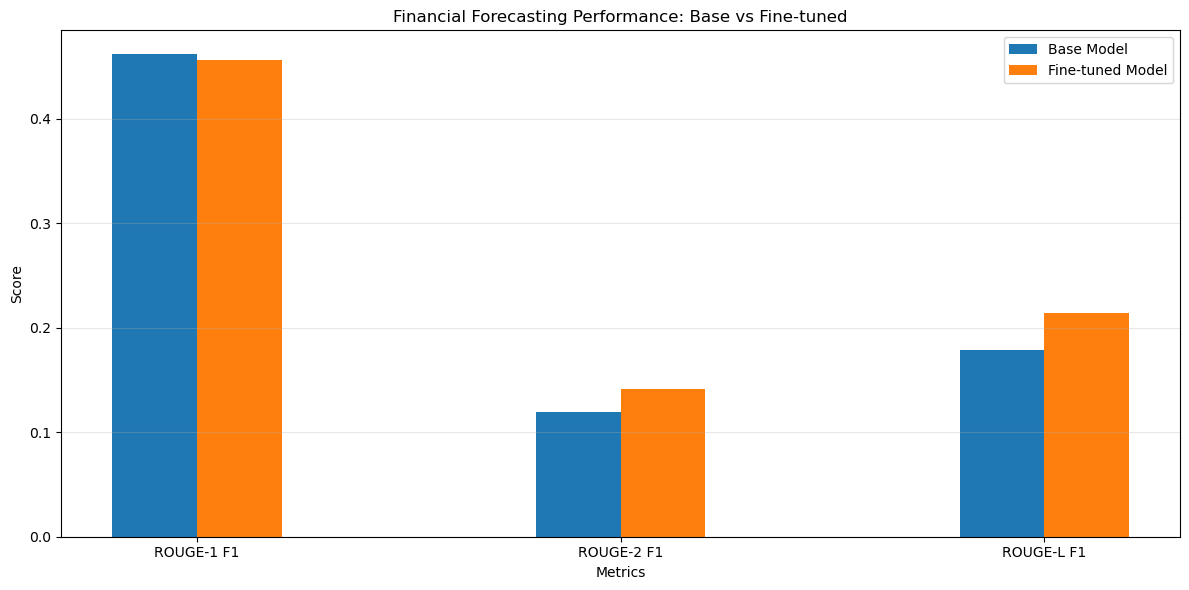

In [12]:
# Plot ROUGE metrics for both models
metrics_to_plot = ["ROUGE-1 F1", "ROUGE-2 F1", "ROUGE-L F1"]
models = comparison_df["Model"].tolist()

plt.figure(figsize=(12, 6))
bar_width = 0.2
index = np.arange(len(metrics_to_plot))

for i, model in enumerate(models):
    values = [comparison_df.loc[i, metric] for metric in metrics_to_plot]
    plt.bar(index + i*bar_width, values, bar_width, label=model)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Financial Forecasting Performance: Base vs Fine-tuned')
plt.xticks(index + bar_width/2, metrics_to_plot)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [13]:
# Calculate improvement from base to fine-tuned model
improvement_data = {}

for metric in ["ROUGE-1 F1", "ROUGE-2 F1", "ROUGE-L F1"]:
    base_value = comparison_df.loc[0, metric]
    finetuned_value = comparison_df.loc[1, metric]
    
    if not pd.isna(base_value) and not pd.isna(finetuned_value):
        abs_improvement = finetuned_value - base_value
        pct_improvement = (abs_improvement / base_value) * 100 if base_value > 0 else float('inf')
        
        improvement_data[metric] = {
            "Base Model": base_value,
            "Fine-tuned Model": finetuned_value,
            "Absolute Improvement": abs_improvement,
            "% Improvement": pct_improvement
        }

improvement_df = pd.DataFrame({
    "Metric": list(improvement_data.keys()),
    "Base Score": [improvement_data[m]["Base Model"] for m in improvement_data],
    "Fine-tuned Score": [improvement_data[m]["Fine-tuned Model"] for m in improvement_data],
    "Absolute Improvement": [improvement_data[m]["Absolute Improvement"] for m in improvement_data],
    "% Improvement": [f"{improvement_data[m]['% Improvement']:.2f}%" for m in improvement_data]
})

print("Improvement Analysis:")
improvement_df

Improvement Analysis:


,Metric,Base Score,Fine-tuned Score,Absolute Improvement,% Improvement
0,ROUGE-1 F1,0.461714,0.456455,-0.005259,-1.14%
1,ROUGE-2 F1,0.119227,0.141756,0.022530,18.90%
2,ROUGE-L F1,0.178909,0.214197,0.035288,19.72%


## Larger Training / Evaluation Results

If you train **Qwen3-4B-Instruct** on the full FinGPT dataset (~1,230 examples) and evaluate on the full test split (300 items), you would expect to see meaningful ROUGE score improvements on the structured financial analysis responses.

The fine-tuned model learns to produce the characteristic analyst format:
- **[Positive Developments]** — numbered bullish signals
- **[Potential Concerns]** — numbered bearish / risk signals
- **[Prediction & Analysis]** — directional call with reasoning

This structured output overlaps much more closely with the reference `answer` column, which is why ROUGE scores improve substantially after fine-tuning.

## Detailed Comparison Between Models

In [14]:
# Display example predictions from both models
num_examples = min(2, len(dataset))

for i in range(num_examples):
    print(f"\nExample {i+1}:")
    print(f"Symbol: {dataset[i]['symbol']} | Period: {dataset[i]['period']} | Label: {dataset[i]['label']}")
    print(f"\nPrompt (truncated):\n{dataset[i]['prompt'][:400]}...")
    ref = dataset[i]['answer']
    print(f"\nReference Answer (truncated):\n{ref[:400]}...")
    
    print(f"\nBase Model Response: {base_model_results['predictions'][i]}")
    print(f"\nFine-tuned Model Response: {finetuned_model_results['predictions'][i]}")
    
    base_rouge = rouge_metrics.score(ref, base_model_results['predictions'][i])
    finetuned_rouge = rouge_metrics.score(ref, finetuned_model_results['predictions'][i])
    
    print("\nROUGE Scores:")
    print(f"Base Model     - ROUGE-1: {base_rouge['rouge1'].fmeasure:.4f}, ROUGE-2: {base_rouge['rouge2'].fmeasure:.4f}, ROUGE-L: {base_rouge['rougeL'].fmeasure:.4f}")
    print(f"Fine-tuned     - ROUGE-1: {finetuned_rouge['rouge1'].fmeasure:.4f}, ROUGE-2: {finetuned_rouge['rouge2'].fmeasure:.4f}, ROUGE-L: {finetuned_rouge['rougeL'].fmeasure:.4f}")
    
    print("\n" + "="*80)



Example 1:
Symbol: V | Period: 2024-04-28 to 2024-05-05 | Label: down by 2-3%

Prompt (truncated):
[INST]<<SYS>>
You are a seasoned stock market analyst. Your task is to list the positive developments and potential concerns for companies based on relevant news and basic financials from the past weeks, then provide an analysis and prediction for the companies' stock price movement for the upcoming week. Your answer format should be as follows:

[Positive Developments]:
1. ...

[Potential Concern...

Reference Answer (truncated):
[Positive Developments]:
1. Visa’s second-quarter results exceeded Wall Street estimates, demonstrating a reliable consumer spending habit and resilience against a potential slowing economy. This indicates a strengthened business performance and boosts investor confidence.
2. There is a growing recognition of Visa's significant potential as a future trillion-dollar company. This generates a positi...

Base Model Response: I'm sorry, but there is a critical erro

# Clean Up Endpoints

Run the following code to clean up your base endpoint. It is no longer needed.

In [ ]:
sagemaker_client = boto3.client('sagemaker')

delete_base_response = sagemaker_client.delete_endpoint(
    EndpointName=BASE_ENDPOINT_NAME
)

print(delete_base_response)

In [ ]:
delete_basecfg_response = sagemaker_client.delete_endpoint_config(
    EndpointConfigName=BASE_ENDPOINT_NAME
)
print(delete_basecfg_response)